# 8 · The full spiking model, and what the second layer is worth

**What you will do:** run a four-digit subset through a population of Hodgkin–Huxley neurons driven by the SHD spike trains themselves, then analyse the layer you simulated with the same code notebooks 2 and 3 used on the layer you were given.

**What you should take away:** [docs/05-routes.md](../docs/05-routes.md) sets route B's minimum viable result as *decoding accuracy from the circuit layer versus from the input layer, with matched readouts and matched dimensionality*. This notebook produces that number and its controls.

Nothing here is filtered, pooled, compressed, rate-coded or injected as a current. The input is the recorded event list, the drive is a synaptic conductance, and the simulation runs in real time at 0.1 ms, so nothing below can be blamed on preprocessing.

Runtime: about twelve minutes on CPU, two passes over 160 trials.

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import jax
import jax.numpy as jnp

from compbio2026 import data, decoding, filters, geometry, plotting, spiking

plotting.apply_style()
rng = np.random.default_rng(2026)

SIM_DT = 0.1        # ms, integration timestep
T_MAX = 700.0       # ms, real trial duration
BIN_MS = 20.0       # ms, analysis bin for both layers
N_OUT = 24          # downstream cells
FAN_IN = 60         # SHD channels per cell
G_SYN = 3e-4        # uS per synapse
BATCH = 8           # trials simulated at once; bounded by the drive array, not the network

DIGITS = ["one", "three", "six", "seven"]
N_PER = 40

In [2]:
shd = data.load("train")
idx = np.concatenate([
    rng.choice(np.flatnonzero(shd.labels == data.DIGIT_KEYS.index(d)), N_PER, replace=False)
    for d in DIGITS
])
y = np.repeat(np.arange(len(DIGITS)), N_PER)
order = rng.permutation(len(idx))
idx, y = idx[order], y[order]

print(f"{len(idx)} trials, {len(DIGITS)} classes, chance = {decoding.chance_level(y):.3f}")

160 trials, 4 classes, chance = 0.250


## The model

```
SHD event list  ->  clamped presynaptic terminals  ->  IonotropicSynapse  ->  HH cells  ->  output spikes
  700 channels        one per channel                  gS, e_syn = 0 mV       24 cells      analysed below
                      -70 mV, +20 mV for 1 ms          tau_syn = 5 ms         real time
```

Each downstream cell is assigned a best frequency and draws `FAN_IN` presynaptic channels from a Gaussian around it — convergence with a receptive field, the mechanism pooling was a stand-in for. Synapses are excitatory and identical; there is no inhibition, no plasticity and no recurrence. Those limits are listed again at the end.

In [3]:
t0 = time.time()
M = spiking.tonotopic_connectivity(700, N_OUT, fan_in=FAN_IN, width=35.0,
                                   rng=np.random.default_rng(0))
net = spiking.build_layer(M, tau_syn_ms=5.0, e_syn_mV=0.0)
n_edges = len(net.edges)
run = jax.jit(jax.vmap(spiking.make_simulator(net, n_in=700, dt_ms=SIM_DT), in_axes=(None, 0)))
print(f"built in {time.time() - t0:.0f}s: {n_edges} synapses onto {N_OUT} HH cells")

built in 4s: 1440 synapses onto 24 HH cells


In [4]:
def simulate_all(run_fn, g_syn, n_syn, trials, keep_first=True):
    """Simulate every trial in batches; return binned output spikes and the first batch's voltages.

    The drive array is what limits the batch: 700 channels x 7000 steps x 4 bytes
    is 20 MB per trial, so it is built and thrown away batch by batch.
    """
    counts, v_first = [], None
    g = jnp.full((n_syn,), g_syn)
    t0 = time.time()
    for start in range(0, len(trials), BATCH):
        chunk = trials[start:start + BATCH]
        V_in = jnp.array(spiking.spike_drive(shd, chunk, dt_ms=SIM_DT, t_max_ms=T_MAX))
        V = np.asarray(run_fn(g, V_in))
        counts.append(spiking.spike_counts(V, SIM_DT, bin_ms=BIN_MS))
        if keep_first and v_first is None:
            v_first = V
        done = start + len(chunk)
        print(f"  {done:3d}/{len(trials)} trials  {time.time() - t0:5.0f}s", end="\r")
    print()
    return np.concatenate(counts, axis=0), v_first


S, V_demo = simulate_all(run, G_SYN, n_edges, idx)
print(f"layer 2 spike counts: {S.shape} = (trials, cells, bins of {BIN_MS:.0f} ms)")
print(f"mean rate {S.sum(-1).mean() / (T_MAX / 1e3):.1f} Hz, "
      f"{int((S.sum(-1).mean(0) < 1).sum())} silent cells")

  160/160 trials    327s
layer 2 spike counts: (160, 24, 35) = (trials, cells, bins of 20 ms)
mean rate 20.3 Hz, 0 silent cells


## What the layer does

Input on the left, output on the right, same trial and same time axis. The second layer is 700 channels onto 24 cells, so it is sparser by construction; the question is whether it is *only* sparser.

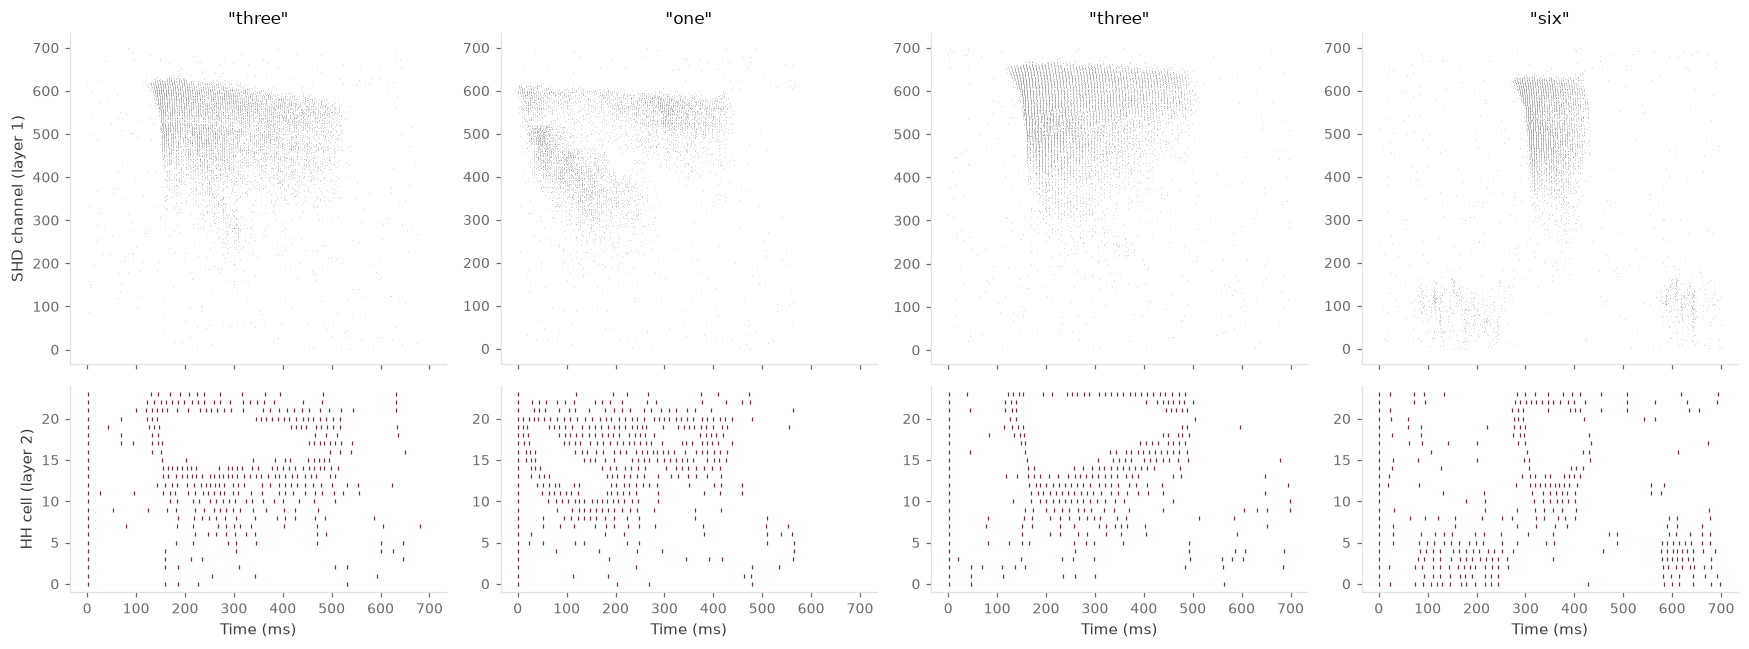

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True,
                         gridspec_kw={"height_ratios": [1.6, 1]})
for j in range(4):
    ev = data.events(shd, idx[j], t_max_ms=T_MAX)
    axes[0, j].scatter(ev[:, 1], ev[:, 0], s=0.3, c=plotting.INK, marker=".",
                       linewidths=0, alpha=0.6)
    axes[0, j].set_title(f'"{DIGITS[y[j]]}"')
    cell, step = np.nonzero(spiking.detect_spikes(V_demo[j]))
    axes[1, j].scatter(step * SIM_DT, cell, s=6, c=plotting.ACCENT, marker="|", linewidths=0.8)
    axes[1, j].set_xlabel("Time (ms)")
    axes[1, j].set_ylim(-1, N_OUT)
axes[0, 0].set_ylabel("SHD channel (layer 1)")
axes[1, 0].set_ylabel("HH cell (layer 2)")
fig.tight_layout()
plotting.savefig(fig, "08_two_layers", outdir="../plots")

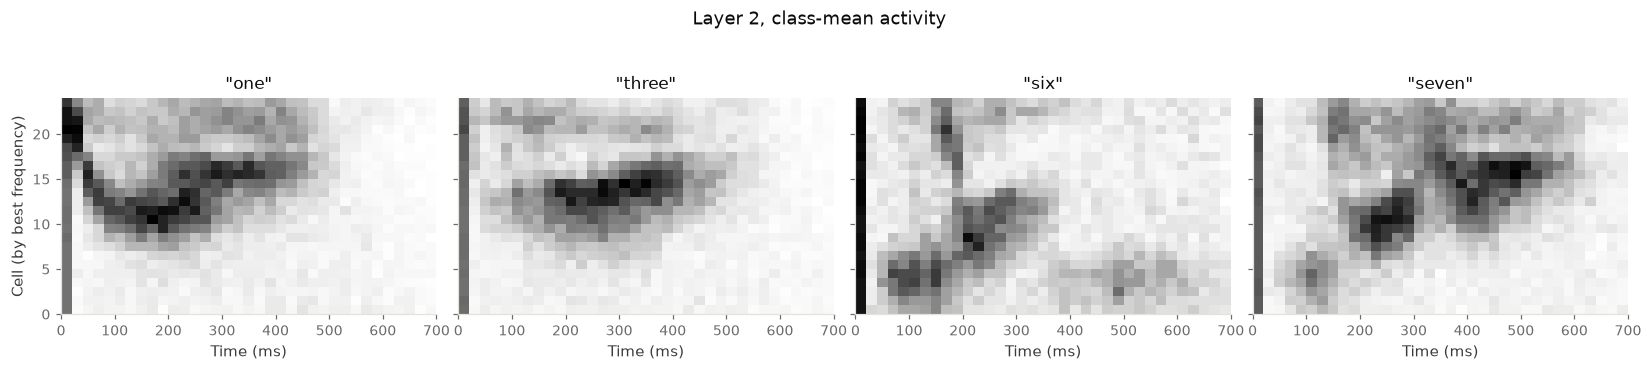

In [6]:
fig, axes = plt.subplots(1, len(DIGITS), figsize=(15, 3.2), sharey=True)
for j, word in enumerate(DIGITS):
    axes[j].imshow(S[y == j].mean(0), aspect="auto", origin="lower", cmap="Greys",
                   extent=[0, T_MAX, 0, N_OUT], interpolation="nearest")
    axes[j].set_title(f'"{word}"')
    axes[j].set_xlabel("Time (ms)")
axes[0].set_ylabel("Cell (by best frequency)")
fig.suptitle("Layer 2, class-mean activity", y=1.04)
fig.tight_layout()
plotting.savefig(fig, "08_class_means", outdir="../plots")

The class means are distinguishable by eye, which is the trap notebook 2 was about. The rest of the notebook measures them instead.

Before reading anything into these panels: the dark first column, and the vertical line of spikes at *t* = 0 in the raster above it, are not a response to the stimulus. Every cell fires once as the integrator settles from its initial condition onto rest. It is identical on every trial of every class, so it cannot help the decoder, but it does sit in the first analysis bin of every number below. Discarding the first 50 ms is the right thing to do in an analysis you intend to defend.

## The comparison route B asks for

Three numbers, all with the same readout and the same cross-validation:

1. **Layer 2** — 24 simulated cells × 35 bins = 840 features.
2. **Layer 1, matched** — the input reduced to 24 channels × 35 bins = 840 features, by both reductions from notebook 6. Pooling to 24 bands is the closest analytic analogue of what the circuit does; selecting 24 channels is the analogue of not doing the averaging.
3. **Layer 1, full** — all 700 channels × 35 bins. An upper reference, not a fair comparison to anything.

Matching the feature count is not a formality. A layer that halves the dimensionality usually loses accuracy for that reason alone, and attributing the loss to biophysics when width caused it is the standard way this experiment goes wrong.

In [7]:
X1, _, _ = data.build_design_matrix(shd, bin_ms=BIN_MS, t_max_ms=T_MAX, trials=idx)
X1_pooled = filters.pool_channels(X1, N_OUT)
X1_selected, kept = filters.select_channels(X1, N_OUT, method="uniform")

readout = decoding.make_readout("ridge")
rows = []
for name, A in [("layer 2 (HH cells)", S),
                ("layer 1, pooled to 24 bands", X1_pooled),
                ("layer 1, 24 selected channels", X1_selected),
                ("layer 1, all 700 channels", X1)]:
    F = data.flatten(A)
    r = decoding.decode(F, y, estimator=readout)
    rows.append({"representation": name, "features": F.shape[1],
                 "accuracy": r["mean"], "sd": r["std"]})
rows.append({"representation": "chance", "features": 0,
             "accuracy": decoding.chance_level(y), "sd": 0.0})
result = pd.DataFrame(rows).set_index("representation")
result.round(3)

,features,accuracy,sd
representation,,,
layer 2 (HH cells),840,0.925,0.032
"layer 1, pooled to 24 bands",840,0.888,0.061
"layer 1, 24 selected channels",840,0.812,0.059
"layer 1, all 700 channels",24500,0.906,0.034
chance,0,0.250,0.000


In [8]:
null = decoding.shuffle_control(data.flatten(S), y, estimator=readout)
print(f"layer 2 shuffled-label null: {null.mean():.3f} +/- {null.std():.3f}  "
      f"(vs {result.loc['layer 2 (HH cells)', 'accuracy']:.3f} real)")

layer 2 shuffled-label null: 0.239 +/- 0.035  (vs 0.925 real)


## Decoding as the word unfolds

Everything above collapsed each trial into one 840-dimensional vector — a summary of the whole presentation, available only once the word has finished. A downstream reader does not get that. It has to commit while the word is still arriving, and *when* it could is a separate question from whether the information is there at all.

`decoding.accuracy_over_time` is the same function notebook 3 used on the input, so the two curves below are directly comparable to it.

- **Instantaneous** — a readout on the population state in one 20 ms bin, which localises where in the trial the class information sits.
- **Cumulative** — a readout on every bin up to that point, which is what a reader integrating over time has available. At the last bin it is fitting exactly the 840 features of the table above, so the curve has to end on that number.

In [9]:
t_bins = (np.arange(S.shape[2]) + 0.5) * BIN_MS

curves = {}
for name, A, cumulative in [("layer 2, instantaneous", S, False),
                            ("layer 2, cumulative", S, True),
                            ("layer 1 pooled, cumulative", X1_pooled, True)]:
    _, curves[name] = decoding.accuracy_over_time(A, y, t_bins, estimator=readout,
                                                  cumulative=cumulative)

cumulative reaches its final 0.925 from 410 ms onwards (90 % of it)
best single 20 ms bin: 0.556 at 90 ms
first bin, which also holds the initialisation transient: 0.344, chance 0.250


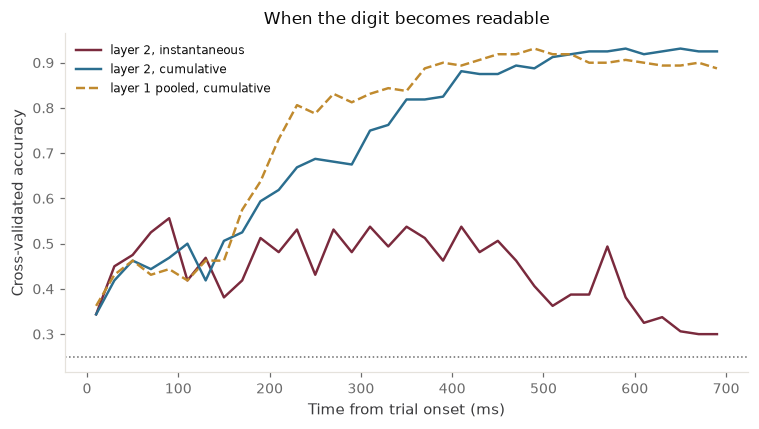

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
for (name, curve), style in zip(curves.items(), ["-", "-", "--"]):
    ax.plot(t_bins, curve, style, lw=1.6, label=name)
ax.axhline(decoding.chance_level(y), ls=":", lw=1, color=plotting.INK_MUTED)
ax.set_xlabel("Time from trial onset (ms)")
ax.set_ylabel("Cross-validated accuracy")
ax.set_title("When the digit becomes readable")
ax.legend(fontsize=8)
fig.tight_layout()
plotting.savefig(fig, "08_accuracy_over_time", outdir="../plots")

cum, inst = curves["layer 2, cumulative"], curves["layer 2, instantaneous"]
print(f"cumulative reaches its final {cum[-1]:.3f} from "
      f"{t_bins[int(np.argmax(cum >= 0.9 * cum[-1]))]:.0f} ms onwards (90 % of it)")
print(f"best single {BIN_MS:.0f} ms bin: {inst.max():.3f} "
      f"at {t_bins[int(np.argmax(inst))]:.0f} ms")
print(f"first bin, which also holds the initialisation transient: {inst[0]:.3f}, "
      f"chance {decoding.chance_level(y):.3f}")

Three things in that figure.

**Nothing happens before about 150 ms.** Both cumulative curves sit near 0.45 until then, and the flat stretch is the recording rather than the circuit: SHD trials begin with a silent lead-in, so there is nothing yet to decode. The first bin sits at 0.344 rather than at chance because it holds 20 ms of real response as well as the initialisation transient.

**Layer 1 is quicker; layer 2 ends up ahead.** The input passes 0.9 by about 300 ms, while the simulated layer does not get there until roughly 500 ms and only overtakes it around 530 ms. That lag is the model's own time constants — a 5 ms synaptic conductance and the membrane that integrates it — and it is the price of having a circuit at all. The whole-trial advantage in the table above is entirely a late-trial effect: a reader forced to answer at 300 ms would be better off with the input.

**No single 20 ms slice carries the digit.** The instantaneous curve never exceeds 0.56 and decays once the word ends, so what the cumulative readout adds is the sequence rather than more neurons. That is the conclusion notebook 3 reached about the input, and the one Cramer et al. reached about spike timing.

One more detail worth not skipping: the layer 1 curve *declines* after 500 ms. Those late bins carry no new class information, so all they contribute is 24 more parameters per bin to fit on 128 training trials. Accuracy falling as you add data is a fitting problem, not a coding one.

## Geometry, on both layers, with the same function

`geometry.summarize` is the call notebook 2 made on the input. Running it on a layer you simulated rather than one you were handed is the only new thing here — and the two rows disagree with the decoding table, which is worth reading rather than smoothing over.

In [11]:
geo = pd.DataFrame([
    dict(layer="layer 1, pooled to 24", **geometry.summarize(data.flatten(X1_pooled), y)),
    dict(layer="layer 2 (HH cells)", **geometry.summarize(data.flatten(S), y)),
]).set_index("layer")
geo.round(3)

,participation_ratio,class_separation,between_class_distance,within_class_radius
layer,,,,
"layer 1, pooled to 24",9.607,0.219,10.441,13.712
layer 2 (HH cells),41.255,0.152,9.641,15.297


The layers differ most in **participation ratio**: the simulated layer spreads over roughly four times as many effective dimensions as the pooled input, from the same number of columns. Pooling 29 neighbouring channels into a band is a smoothing operation and yields a strongly low-rank matrix; spiking does the opposite. Whether the extra dimensions are structure a readout can use or spiking noise is what the decoding number is for.

Class separation moves the other way. It is a Fisher-style ratio of between-class to within-class scatter, and it is *lower* for the simulated layer even though the decoder does better on it. The Fisher index is a single number over isotropic scatter, blind to the case where the discriminative directions are low-variance ones a readout can still find. A geometry summary is not a decoding result, and when they disagree the decoder is the one making a falsifiable claim.

## The control: was the tonotopy doing the work?

Rebuild the layer with the same number of cells and the same fan-in, but with each cell sampling 60 channels uniformly at random instead of from a frequency neighbourhood. If the random layer decodes as well, the tonotopic wiring was decoration and the result is about convergence rather than frequency tuning.

In [12]:
M_rand = spiking.random_connectivity(700, N_OUT, fan_in=FAN_IN, rng=np.random.default_rng(1))
net_rand = spiking.build_layer(M_rand, tau_syn_ms=5.0, e_syn_mV=0.0)
run_rand = jax.jit(jax.vmap(spiking.make_simulator(net_rand, n_in=700, dt_ms=SIM_DT),
                            in_axes=(None, 0)))
S_rand, _ = simulate_all(run_rand, G_SYN, len(net_rand.edges), idx, keep_first=False)

r_rand = decoding.decode(data.flatten(S_rand), y, estimator=readout)
print(f"tonotopic connectivity  {result.loc['layer 2 (HH cells)', 'accuracy']:.3f}")
print(f"random connectivity     {r_rand['mean']:.3f}")
print(f"chance                  {decoding.chance_level(y):.3f}")

  160/160 trials    331s


tonotopic connectivity  0.925
random connectivity     0.719
chance                  0.250


## Reading the result

Three outcomes are possible and they are different papers.

- **Layer 2 below matched layer 1.** The circuit is a lossy nonlinear map: spiking discards subthreshold information, the refractory period censors high rates, and nothing was optimised to preserve class identity. Say how much was lost and where.
- **Layer 2 at matched layer 1.** The circuit preserved what a linear readout could already use. This is the one that most needs the shuffled-label null printed beside it.
- **Layer 2 above matched layer 1.** Check that the readout is not exploiting the *rate* of the layer rather than its temporal structure, that the difference survives a change of `BIN_MS`, and that it survives the random-connectivity control.

This run gave the third: layer 2 at 0.925, above both matched baselines (0.888 pooled, 0.812 selected) and above the full 700-channel input at 0.906.

Three things support it. The shuffled-label null sits at chance (0.239). The random-connectivity control drops to 0.719, so the frequency-neighbourhood wiring carries real weight. And no cell is silent, at a mean rate near 20 Hz, so the layer is not winning by being loud in a few units.

One thing argues against reading much into it: 0.925 ± 0.032 against 0.888 ± 0.061 is about one standard deviation across five folds of 160 trials. The claim that survives is that **the simulated layer preserves the digit at least as well as the matched input does** — not that it improves on it. The stronger claim would need more trials, a sweep over `BIN_MS` and `G_SYN`, and a control matching firing rate as well as dimensionality.

Either way the statement is about **this** layer with **these** parameters. `G_SYN`, `FAN_IN`, `width` and `tau_syn_ms` were set to make the cells fire in a plausible range, and notebook 7 showed the firing rate is not a monotone function of `G_SYN`. One point in that space is not a claim about circuits.

---

## What is wrong with this model

State all of it in your report.

- **No recurrence.** 24 independent cells cannot do anything a pointwise nonlinearity could not. Sustained activity, normalisation and sequence sensitivity all need connections between the output cells. This is the most valuable extension, and it is exercise 1.
- **No inhibition.** Every synapse is excitatory with `e_syn = 0`, so the layer has no gain control — which is why `G_SYN` had to be tuned by hand.
- **The receptive fields were assigned.** The tonotopic fan-in is a hypothesis about the circuit, not something the data chose.
- **One synapse type, one time constant.** No short-term depression, which is prominent at exactly this stage of the auditory pathway and would change the response to sustained input.
- **Four digits, 160 trials.** The standard error is a few percent. Do not read the third decimal place.
- **The presynaptic voltage is a stand-in.** Its amplitude and 1 ms width set how much transmitter one spike releases, and nothing in SHD constrains them.
- **The first bin is an initialisation transient**, kept visible rather than quietly removed.

## Exercises

1. **Add recurrence.** `jx.connect` the output cells to each other, some excitatory and some with `e_syn = -80`, and re-run the decoding comparison. This is the experiment route B is really about.
2. **Sweep what you tuned by hand.** Show the decoding result as a function of `G_SYN`, `FAN_IN` and `width`, and report whether your conclusion depends on the point you happened to pick.
3. **Change the analysis bin.** Does the layer 1 versus layer 2 ordering survive `BIN_MS` of 5 ms and 100 ms?
4. **Train the synapses.** `spiking.make_simulator(net, 700, checkpoints=[70, 100])` gives gradients through the whole model. Optimise `G_SYN` per synapse and compare the learned receptive fields with the assigned ones. Time one epoch before committing.
5. **Follow the ablation question upward.** Notebook 4 found the input code massively redundant. Run `selection.compare_selectors` on `S` and compare the ablation gap with the one you found for the input.
6. **Discard the transient.** Drop the first 50 ms from both layers before binning and re-run the decoding table. The numbers should barely move; if they do, something you thought was a response was the initial condition.
7. **Give the circuit something to do.** The comparison is close partly because the task is nearly linear already. Build one that requires memory across the trial — the same two digits in a different order — and ask again.

Next: **[9 · A state matrix](09_state_matrix.ipynb)** — the same idea with one population vector per presentation instead of the whole time course.